In [ ]:
#import numpy==v1.24.3
#import pandas==v2.0.1
#import scikit-learn==v1.2.2
#import matplotlib==v3.7.1
#import seaborn==v0.12.2
#import shap==v0.41.0
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from collections import Counter
######----------For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(15,5)})
plt.style.use('fivethirtyeight')

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving barriers_org.csv to barriers_org.csv


In [ ]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv('barriers_org.csv')

In [ ]:
data

,age,abortion,birth_5yr,No_children,contra_use,country,education,fieldworker,insurance,marital,Media,pregnant,religion,residence,sex_HH,visited_HF,wealth,working,barrier
0,7,0,0,3,0,1,0,0,0.0,2,1,0,1.0,2,2,1,1,1,1
1,1,0,0,0,0,1,1,0,0.0,1,1,0,1.0,2,2,1,1,1,1
2,4,0,0,1,0,1,1,0,0.0,2,0,0,2.0,2,1,1,1,1,1
3,7,0,0,3,0,1,1,0,0.0,2,0,0,1.0,2,2,1,3,1,1
4,1,0,0,0,0,1,1,0,0.0,1,1,0,1.0,2,2,1,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178762,1,0,0,0,0,11,2,0,0.0,1,1,0,4.0,2,2,0,3,0,0
178763,6,0,1,1,1,11,1,0,0.0,2,1,0,4.0,2,1,1,2,0,0
178764,4,0,0,1,1,11,2,0,0.0,3,1,0,3.0,2,2,1,1,0,1
178765,5,0,0,1,1,11,2,0,0.0,2,1,0,4.0,2,2,1,1,0,1


In [ ]:
print(data.columns) # to show the columns of IV variables

Index(['age', 'abortion', 'birth_5yr', 'No_children', 'contra_use', 'country',
       'education', 'fieldworker', 'insurance', 'marital', 'Media', 'pregnant',
       'religion', 'residence', 'sex_HH', 'visited_HF', 'wealth', 'working',
       'barrier'],
      dtype='object')


In [ ]:
data.nunique()

,0
age,7
abortion,2
birth_5yr,2
No_children,3
contra_use,2
country,11
education,4
fieldworker,2
insurance,2
marital,3


In [ ]:
# Check for missing values in each column
print(data.isnull().sum())

age                0
abortion           0
birth_5yr          0
No_children        0
contra_use         0
country            0
education          0
fieldworker        0
insurance      16901
marital            0
Media              0
pregnant           0
religion       15254
residence          0
sex_HH             0
visited_HF         0
wealth             0
working            0
barrier            0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# Step 1: Identify non-numeric columns
non_numeric_cols = data.select_dtypes(include=['object', 'string']).columns

# Step 2: Flag problematic entries (optional but useful for review)
problematic = data[non_numeric_cols].applymap(lambda x: not pd.to_numeric(x, errors='coerce') if isinstance(x, str) else False)

# Step 3: Encode non-numeric columns (if you want to impute them)
# Option A: Drop them if irrelevant
# df_numeric = df.drop(columns=non_numeric_cols)

# Option B: Encode them (Label Encoding or One-Hot)
df_encoded = data.copy()
for col in non_numeric_cols:
    df_encoded[col] = pd.factorize(data[col])[0].astype(float)  # NaNs preserved

# Step 4: Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
df_imputed_array = imputer.fit_transform(df_encoded)

# Step 5: Restore DataFrame
df_imputed = pd.DataFrame(df_imputed_array, columns=data.columns)

/tmp/ipykernel_31623/3182186466.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  problematic = data[non_numeric_cols].applymap(lambda x: not pd.to_numeric(x, errors='coerce') if isinstance(x, str) else False)


In [ ]:
# Check for missing values in each column
print(df_imputed.isnull().sum())

age            0
abortion       0
birth_5yr      0
No_children    0
contra_use     0
country        0
education      0
fieldworker    0
insurance      0
marital        0
Media          0
pregnant       0
religion       0
residence      0
sex_HH         0
visited_HF     0
wealth         0
working        0
barrier        0
dtype: int64


In [ ]:
# Step 6: Display a preview
print("🔍 Imputed Data Preview:")
print(df_imputed.head())

# Step 7: Save to CSV (preserving original structure)
df_imputed.to_csv('imputed_outputt.csv', index=False)
print("✅ Imputed data saved as 'imputed_outputt.csv'")

🔍 Imputed Data Preview:
   age  abortion  birth_5yr  No_children  contra_use  country  education  \
0  7.0       0.0        0.0          3.0         0.0      1.0        0.0   
1  1.0       0.0        0.0          0.0         0.0      1.0        1.0   
2  4.0       0.0        0.0          1.0         0.0      1.0        1.0   
3  7.0       0.0        0.0          3.0         0.0      1.0        1.0   
4  1.0       0.0        0.0          0.0         0.0      1.0        1.0   

   fieldworker  insurance  marital  Media  pregnant  religion  residence  \
0          0.0        0.0      2.0    1.0       0.0       1.0        2.0   
1          0.0        0.0      1.0    1.0       0.0       1.0        2.0   
2          0.0        0.0      2.0    0.0       0.0       2.0        2.0   
3          0.0        0.0      2.0    0.0       0.0       1.0        2.0   
4          0.0        0.0      1.0    1.0       0.0       1.0        2.0   

   sex_HH  visited_HF  wealth  working  barrier  
0     2.0   

In [ ]:
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 6: Display a preview
print("🔍 Imputed Data Preview:")
print(df_imputed.head())

# Step 7: Save to CSV (preserving original structure) into Google Drive
output_path = '/content/drive/MyDrive/imputed_outputt.csv'
df_imputed.to_csv(output_path, index=False)

print(f"✅ Imputed data saved as '{output_path}'")


Mounted at /content/drive
🔍 Imputed Data Preview:
   age  abortion  birth_5yr  No_children  contra_use  country  education  \
0  7.0       0.0        0.0          3.0         0.0      1.0        0.0   
1  1.0       0.0        0.0          0.0         0.0      1.0        1.0   
2  4.0       0.0        0.0          1.0         0.0      1.0        1.0   
3  7.0       0.0        0.0          3.0         0.0      1.0        1.0   
4  1.0       0.0        0.0          0.0         0.0      1.0        1.0   

   fieldworker  insurance  marital  Media  pregnant  religion  residence  \
0          0.0        0.0      2.0    1.0       0.0       1.0        2.0   
1          0.0        0.0      1.0    1.0       0.0       1.0        2.0   
2          0.0        0.0      2.0    0.0       0.0       2.0        2.0   
3          0.0        0.0      2.0    0.0       0.0       1.0        2.0   
4          0.0        0.0      1.0    1.0       0.0       1.0        2.0   

   sex_HH  visited_HF  wealth  worki

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving imputed_output.csv to imputed_output.csv


In [ ]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv('imputed_output.csv')

In [ ]:
# Check for missing values in each column
print(data.isnull().sum())

age            0
abortion       0
birth_5yr      0
no_children    0
contra_use     0
country        0
education      0
fieldworker    0
insurance      0
marital        0
Media          0
pregnant       0
religion       0
residence      0
sex_HH         0
visited_HF     0
wealth         0
working        0
barrier        0
dtype: int64


In [ ]:
import pandas as pd

# Sample DataFrame (replace with your own)

# Display unique values for each column

for col in data.columns:
    print(f"\nColumn: {col}")
    counts = data[col].value_counts(dropna=False)
    percentages = data[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary)





Column: age
     Count  Percentage (%)
age                       
1    39578           22.14
2    33893           18.96
3    29034           16.24
4    25051           14.01
5    21530           12.04
6    16661            9.32
7    13020            7.28

Column: abortion
           Count  Percentage (%)
abortion                        
0         156451           87.52
1          22316           12.48

Column: birth_5yr
           Count  Percentage (%)
birth_5yr                       
0          89840           50.26
1          88927           49.74

Column: no_children
              Count  Percentage (%)
no_children                        
1            107783           60.29
0             51628           28.88
2             19356           10.83

Column: contra_use
             Count  Percentage (%)
contra_use                        
0           116871           65.38
1            61896           34.62

Column: country
         Count  Percentage (%)
country                       
5  

In [ ]:
import pandas as pd




# List of categorical columns to encode
categorical_cols = [
   'age', 'abortion', 'birth_5yr', '0_children', 'contra_use', 'country',
       'education', 'fieldworker', 'insurance', 'marital', 'Media', 'pregnant',
       'religion', 'residence', 'sex_HH', 'visited_HF', 'wealth', 'working',
       'barrier'
]

# Apply one-hot encoding with dtype=int to force 0/1
df = pd.get_dummies(data, columns=categorical_cols, drop_first=False, dtype=int)

print(df.head())





   age_1  age_2  age_3  age_4  age_5  age_6  age_7  abortion_0  abortion_1  \
0      0      0      0      0      0      0      1           1           0   
1      1      0      0      0      0      0      0           1           0   
2      0      0      0      1      0      0      0           1           0   
3      0      0      0      0      0      0      1           1           0   
4      1      0      0      0      0      0      0           1           0   

   birth_5yr_0  ...  sex_HH_2  visited_HF_0  visited_HF_1  wealth_1  wealth_2  \
0            1  ...         1             0             1         1         0   
1            1  ...         1             0             1         1         0   
2            1  ...         0             0             1         1         0   
3            1  ...         1             0             1         0         0   
4            1  ...         1             0             1         0         0   

   wealth_3  working_0  working_1  barrier_0

In [ ]:
import pandas as pd



# List of original categorical variables
original_vars = [
'age', 'abortion', 'birth_5yr', '0_children', 'contra_use', 'country',
       'education', 'fieldworker', 'insurance', 'marital', 'Media', 'pregnant',
       'religion', 'residence', 'sex_HH', 'visited_HF', 'wealth', 'working',
       'barrier'
]

# Identify and drop the first dummy column for each variable
for var in original_vars:
    # Find all dummy columns that start with the variable name + underscore
    dummy_cols = [col for col in df.columns if col.startswith(var.strip() + '_')]

    # Sort to ensure consistent order, then drop the first one
    if dummy_cols:
        dummy_cols.sort()
        df.drop(columns=dummy_cols[0], inplace=True)

# Display the cleaned DataFrame
print(df.head())


   age_2  age_3  age_4  age_5  age_6  age_7  abortion_1  birth_5yr_1  \
0      0      0      0      0      0      1           0            0   
1      0      0      0      0      0      0           0            0   
2      0      0      1      0      0      0           0            0   
3      0      0      0      0      0      1           0            0   
4      0      0      0      0      0      0           0            0   

   0_children_1  0_children_3  ...  religion_2  religion_3  religion_4  \
0             0             1  ...           0           0           0   
1             0             0  ...           0           0           0   
2             1             0  ...           1           0           0   
3             0             1  ...           0           0           0   
4             0             0  ...           0           0           0   

   residence_2  sex_HH_2  visited_HF_1  wealth_2  wealth_3  working_1  \
0            1         1             1         0 

In [ ]:
df.nunique()


,0
age_2,2
age_3,2
age_4,2
age_5,2
age_6,2
age_7,2
abortion_1,2
birth_5yr_1,2
0_children_1,2
0_children_3,2


In [ ]:
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

# Save to a folder in your Drive
df.to_csv('/content/drive/MyDrive/df.csv', index=False)

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Barrier.csv to Barrier.csv


In [ ]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv('Barrier.csv')

In [ ]:
data

,age_2,age_3,age_4,age_5,age_6,age_7,abortion_1,birth_5yr_1,no_children_1,no_children_2,...,religion_2,religion_3,religion_4,residence_2,sex_HH_2,visited_HF_1,wealth_2,wealth_3,working_1,barrier
0,0,0,0,0,0,1,0,0,0,1,...,0,0,0,1,1,1,0,0,1,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,1,1
2,0,0,1,0,0,0,0,0,1,0,...,1,0,0,1,0,1,0,0,1,1
3,0,0,0,0,0,1,0,0,0,1,...,0,0,0,1,1,1,0,1,1,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178762,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,1,0,0
178763,0,0,0,0,1,0,0,1,1,0,...,0,0,1,1,0,1,1,0,0,0
178764,0,0,1,0,0,0,0,0,1,0,...,0,1,0,1,1,1,0,0,0,1
178765,0,0,0,1,0,0,0,0,1,0,...,0,0,1,1,1,1,0,0,0,1


In [ ]:
# Check for missing values in each column
print(data.isnull().sum())

age_2            0
age_3            0
age_4            0
age_5            0
age_6            0
age_7            0
abortion_1       0
birth_5yr_1      0
no_children_1    0
no_children_2    0
contra_use_1     0
country_2        0
country_3        0
country_4        0
country_5        0
country_6        0
country_7        0
country_8        0
country_9        0
country_10       0
country_11       0
education_1      0
education_2      0
education_3      0
fieldworker_1    0
insurance_1      0
marital_2        0
marital_3        0
Media_1          0
pregnant_1       0
religion_2       0
religion_3       0
religion_4       0
residence_2      0
sex_HH_2         0
visited_HF_1     0
wealth_2         0
wealth_3         0
working_1        0
barrier          0
dtype: int64


In [ ]:
X = data.drop('barrier', axis=1)
y = data['barrier']


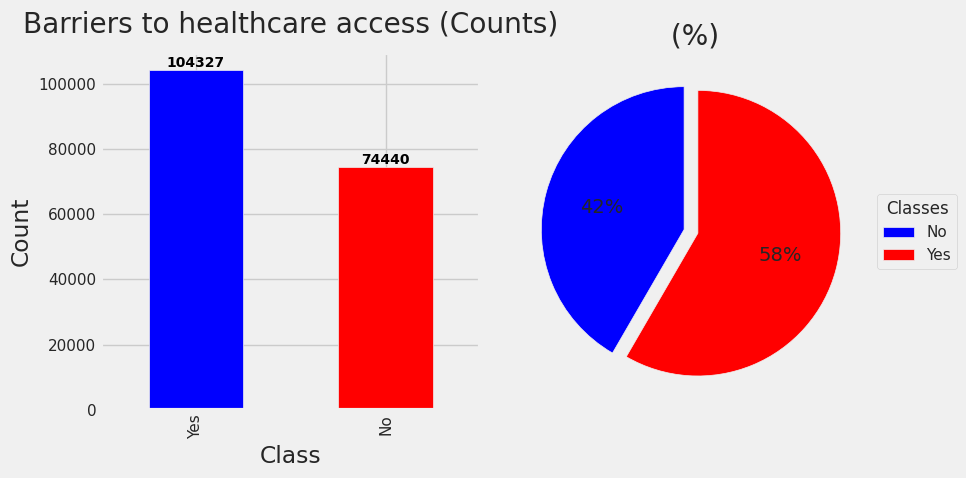

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load the dataset

target_column = 'barrier'  # Replace with your actual target column name
y = data[target_column]

# Replace 0 with "No" and 1 with "Yes" for better representation
y_mapped = y.map({0: 'No', 1: 'Yes'})

# Count occurrences of each class in the dataset
class_counts = Counter(y_mapped)
class_counts_series = pd.Series(class_counts)

# Colors for "No" and "Yes"
bar_colors = ['blue', 'red']
pie_colors = ['blue', 'red']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Bar Chart ---
axes[0].set_title('Barriers to healthcare access (Counts)', pad=15)
class_counts_series.plot(kind='bar', color=bar_colors, ax=axes[0])

# Add count numbers on top of the bars
for i, count in enumerate(class_counts_series):
    axes[0].text(i, count + 0.5, f"{count}", ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='black')

axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# --- Pie Chart ---
sizes = [class_counts['No'], class_counts['Yes']]
wedges, texts, autotexts = axes[1].pie(
    sizes, autopct='%1.f%%', startangle=90, colors=pie_colors,


  explode = (0.05, 0.05)


)

axes[1].legend(wedges, ['No', 'Yes'], title='Classes',
               loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].set_title(' (%)')

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X = data.drop('barrier', axis=1)
y = data['barrier']


# Step 2: Split Datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
def calculate_metrics(y_true, y_preds, y_probs):
    accuracy = accuracy_score(y_true, y_preds)
    auc_score = roc_auc_score(y_true, y_probs)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    return accuracy, auc_score, precision, recall, f1

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)

# 10-fold CV
rf_acc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
rf_auc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
print("Random Forest Mean CV Accuracy:", rf_acc.mean())
print("Random Forest Mean CV ROC-AUC:", rf_auc.mean())

# Final fit and predictions
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)


Random Forest Mean CV Accuracy: 0.6452490714672401
Random Forest Mean CV ROC-AUC: 0.671044474754139


In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

dt_acc = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='accuracy')
dt_auc = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("Decision Tree Mean CV Accuracy:", dt_acc.mean())
print("Decision Tree Mean CV ROC-AUC:", dt_auc.mean())

dt_model.fit(X_train, y_train)
dt_prob = dt_model.predict_proba(X_test)[:, 1]
dt_pred = dt_model.predict(X_test)


Decision Tree Mean CV Accuracy: 0.6009454048620501
Decision Tree Mean CV ROC-AUC: 0.5975278310513612


In [ ]:
# LightGBM
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lgb_model = LGBMClassifier(random_state=42)

# 10-fold CV
lgb_acc = cross_val_score(lgb_model, X_train, y_train, cv=cv, scoring='accuracy')
lgb_auc = cross_val_score(lgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("LightGBM Mean CV Accuracy:", lgb_acc.mean())
print("LightGBM Mean CV ROC-AUC:", lgb_auc.mean())

# Final fit and predictions
lgb_model.fit(X_train, y_train)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred = lgb_model.predict(X_test)


[LightGBM] [Info] Number of positive: 75115, number of negative: 53596
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 128711, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.583594 -> initscore=0.337546
[LightGBM] [Info] Start training from score 0.337546
[LightGBM] [Info] Number of positive: 75115, number of negative: 53596
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 128711, number of used features: 39
[LightGBM] [Info] [bin

In [ ]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
ada_model = AdaBoostClassifier(random_state=42)

ada_acc = cross_val_score(ada_model, X_train, y_train, cv=cv, scoring='accuracy')
ada_auc = cross_val_score(ada_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("AdaBoost Mean CV Accuracy:", ada_acc.mean())
print("AdaBoost Mean CV ROC-AUC:", ada_auc.mean())

ada_model.fit(X_train, y_train)
ada_prob = ada_model.predict_proba(X_test)[:, 1]
ada_pred = ada_model.predict(X_test)


AdaBoost Mean CV Accuracy: 0.6672121402746244
AdaBoost Mean CV ROC-AUC: 0.7017058503321674


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [ ]:
# CatBoost
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cat_model = CatBoostClassifier(verbose=0, random_state=42)

cat_acc = cross_val_score(cat_model, X_train, y_train, cv=cv, scoring='accuracy')
cat_auc = cross_val_score(cat_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("CatBoost Mean CV Accuracy:", cat_acc.mean())
print("CatBoost Mean CV ROC-AUC:", cat_auc.mean())

cat_model.fit(X_train, y_train)
cat_prob = cat_model.predict_proba(X_test)[:, 1]
cat_pred = cat_model.predict(X_test)


CatBoost Mean CV Accuracy: 0.6766937340966297
CatBoost Mean CV ROC-AUC: 0.7174385762994518


In [ ]:
# XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_acc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')
xgb_auc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("XGBoost Mean CV Accuracy:", xgb_acc.mean())
print("XGBoost Mean CV ROC-AUC:", xgb_auc.mean())

xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:38:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:38:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:38:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:38:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost Mean CV Accuracy: 0.676113349235127
XGBoost Mean CV ROC-AUC: 0.7159931267612325


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:39:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

# 10-fold CV
lr_acc = cross_val_score(lr, X_train, y_train, cv=cv, scoring='accuracy')
lr_auc = cross_val_score(lr, X_train, y_train, cv=cv, scoring='roc_auc')
print("Logistic Regression Mean CV Accuracy:", lr_acc.mean())
print("Logistic Regression Mean CV ROC-AUC:", lr_auc.mean())

# Final fit and predictions
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = lr.predict(X_test)


Logistic Regression Mean CV Accuracy: 0.6704915456585072
Logistic Regression Mean CV ROC-AUC: 0.7088379357787281


In [ ]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="uniform", random_state=42)
dummy_model.fit(X_train, y_train)
dummy_preds = dummy_model.predict(X_test)
dummy_probs = dummy_model.predict_proba(X_test)[:, 1]



                 Model       AUC  Accuracy  Precision    Recall  F1 Score
0           LGBoosting  0.721082  0.680959   0.694558  0.809163  0.747493
1        Random Forest  0.672865  0.646501   0.680251  0.743985  0.710692
2        Decision Tree  0.598200  0.601387   0.665516  0.637257  0.651080
3              XGBoost  0.717700  0.678637   0.695464  0.799387  0.743813
4             AdaBoost  0.704221  0.669799   0.683267  0.809403  0.741006
5             CatBoost  0.719677  0.680707   0.696107  0.803796  0.746085
6  Logistic Regression  0.711091  0.672680   0.685568  0.811176  0.743102


/tmp/ipykernel_31623/879609412.py:51: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray', label="Baseline (Random Guess)")


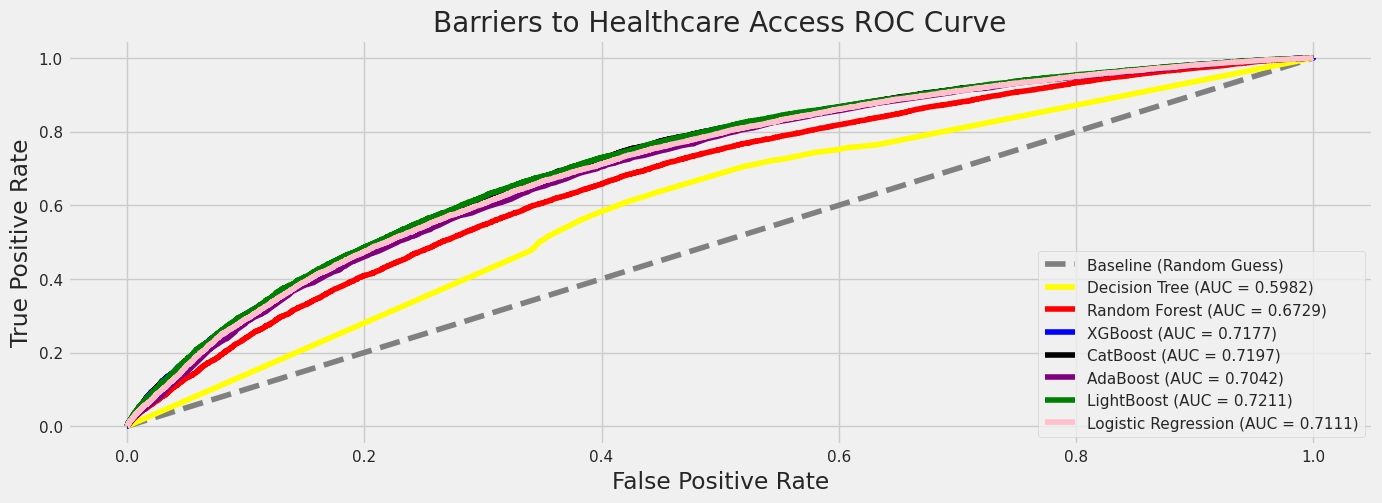

In [ ]:
# Required Libraries
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, roc_curve
)
import pandas as pd

# Consolidated Metrics
metrics = []
roc_curves = []

# Function to Evaluate Models and Compute Metrics
def evaluate_model(name, prob, pred):
    # ROC Curve Data
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_curves.append({'Model': name, 'FPR': fpr, 'TPR': tpr})

    # Metrics Calculation
    auc = roc_auc_score(y_test, prob)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    metrics.append({
      'Model': name,
      'AUC': auc,
      'Accuracy': accuracy,
      'Precision': precision,
      'Recall': recall,
      'F1 Score': f1
    })

# Evaluate Models
evaluate_model('LGBoosting', lgb_prob, lgb_pred)
evaluate_model('Random Forest', rf_prob, rf_pred)
evaluate_model('Decision Tree', dt_prob, dt_pred)
evaluate_model('XGBoost', xgb_prob, xgb_pred)
evaluate_model('AdaBoost', ada_prob, ada_pred)
evaluate_model('CatBoost', cat_prob, cat_pred)
evaluate_model('Logistic Regression', lr_prob, lr_pred)
# Display Consolidated Metrics
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Plot ROC Curve for Each Model

# Baseline (broken line for random classifier)
plt.plot([0, 1], [0, 1], 'k--', color='gray', label="Baseline (Random Guess)")

# Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
plt.plot(dt_fpr, dt_tpr, color='yellow', label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt_prob):.4f})")

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(rf_fpr, rf_tpr, color='red', label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})")

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(xgb_fpr, xgb_tpr, color='blue', label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.4f})")

# CatBoost
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)
plt.plot(cat_fpr, cat_tpr, color='black', label=f"CatBoost (AUC = {roc_auc_score(y_test, cat_prob):.4f})")

# AdaBoost
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)
plt.plot(ada_fpr, ada_tpr, color='purple', label=f"AdaBoost (AUC = {roc_auc_score(y_test, ada_prob):.4f})")

# LightGBM
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_prob)
plt.plot(lgb_fpr, lgb_tpr, color='green', label=f"LightBoost (AUC = {roc_auc_score(y_test, lgb_prob):.4f})")
# Logistic regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(lr_fpr, lr_tpr, color='pink', label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.4f})")

# Plot Customization
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Barriers to Healthcare Access ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define models
lgb_model = LGBMClassifier(random_state=42)
cat_model = CatBoostClassifier(verbose=0, random_state=42)
ada_model = AdaBoostClassifier(random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Collect ROC-AUC scores across folds
lgb_auc = cross_val_score(lgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
cat_auc = cross_val_score(cat_model, X_train, y_train, cv=cv, scoring='roc_auc')
ada_auc = cross_val_score(ada_model, X_train, y_train, cv=cv, scoring='roc_auc')
xgb_auc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')


[LightGBM] [Info] Number of positive: 75115, number of negative: 53596
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 128711, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.583594 -> initscore=0.337546
[LightGBM] [Info] Start training from score 0.337546
[LightGBM] [Info] Number of positive: 75115, number of negative: 53596
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033994 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 128711, number of used features: 39
[LightGBM] [Info] [bin

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:07:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [ ]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(lgb_auc, cat_auc, ada_auc, xgb_auc)
print("Friedman statistic:", stat, "p-value:", p)


Friedman statistic: 26.039999999999992 p-value: 9.355244364196578e-06


In [ ]:
!pip install scikit-posthocs


In [ ]:
import numpy as np
import scikit_posthocs as sp

# Assuming you already collected fold-wise AUCs:
# lgb_auc, cat_auc, ada_auc, xgb_auc (each length 10)

scores = np.array([lgb_auc, cat_auc, ada_auc, xgb_auc]).T
nemenyi = sp.posthoc_nemenyi_friedman(scores)
print(nemenyi)


          0         1         2         3
0  1.000000  0.822401  0.000017  0.028563
1  0.822401  1.000000  0.000799  0.225741
2  0.000017  0.000799  1.000000  0.225741
3  0.028563  0.225741  0.225741  1.000000


In [ ]:
import numpy as np

# Example: fold-wise AUCs (replace with your arrays)
scores = np.array([lgb_auc, cat_auc, ada_auc, xgb_auc]).T

# Rank models per fold (higher AUC = better rank)
ranks = np.argsort(np.argsort(-scores, axis=1), axis=1) + 1
mean_ranks = ranks.mean(axis=0)

names = ["LightGBM", "CatBoost", "AdaBoost", "XGBoost"]
print("Mean ranks:", dict(zip(names, mean_ranks)))


Mean ranks: {'LightGBM': np.float64(1.3), 'CatBoost': np.float64(1.8), 'AdaBoost': np.float64(4.0), 'XGBoost': np.float64(2.9)}


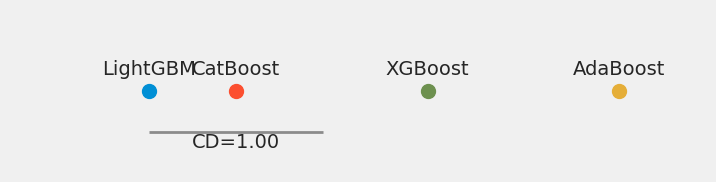

In [ ]:
import matplotlib.pyplot as plt

def critical_difference_diagram(mean_ranks, names, cd=1.0):
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.set_xlim(0.5, len(names)+0.5)
    ax.set_ylim(0, 2)
    ax.axis("off")

    # Plot ranks
    for i, (name, rank) in enumerate(zip(names, mean_ranks)):
        ax.plot(rank, 1, "o", markersize=10)
        ax.text(rank, 1.2, name, ha="center")

    # Draw CD bar
    ax.plot([min(mean_ranks), min(mean_ranks)+cd], [0.5, 0.5], lw=2)
    ax.text(min(mean_ranks)+cd/2, 0.3, f"CD={cd:.2f}", ha="center")

    plt.show()

critical_difference_diagram(mean_ranks, names, cd=1.0)


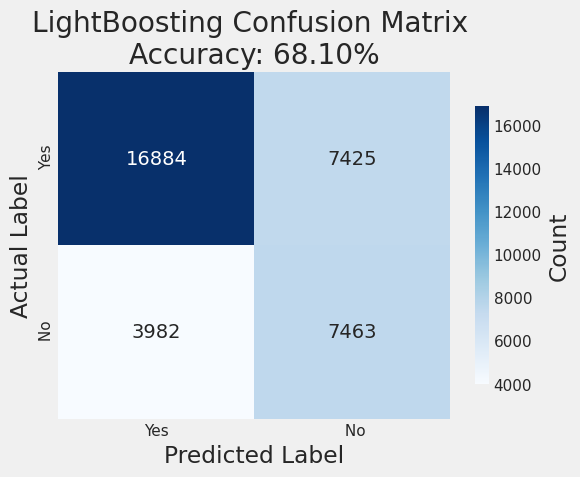

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Predict test labels using XGBoost
lgb_preds = lgb_model.predict(X_test)

# Generate confusion matrix
lgb_cm = confusion_matrix(y_test, lgb_preds)

# Extract values
TP = lgb_cm[1,1]
FP = lgb_cm[0,1]
FN = lgb_cm[1,0]
TN = lgb_cm[0,0]

# Compute accuracy and convert to percentage
lgb_accuracy = accuracy_score(y_test, lgb_preds)
lgb_accuracy_percent = lgb_accuracy * 100

# Create matrix with values
matrix_values = np.array([[TP, FP],
                          [FN, TN]])

# Create matrix with labels
matrix_labels = np.array([[f"{TP}", f"{FP}"],
                          [f"{FN}", f"{TN}"]])

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(matrix_values, annot=matrix_labels, fmt='', cmap='Blues',
            xticklabels=["Yes", " No"],
            yticklabels=[" Yes", " No"],
            cbar=True, cbar_kws={"label": "Count", "shrink": 0.8})

plt.title(f"LightBoosting Confusion Matrix \nAccuracy: {lgb_accuracy_percent:.2f}%")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

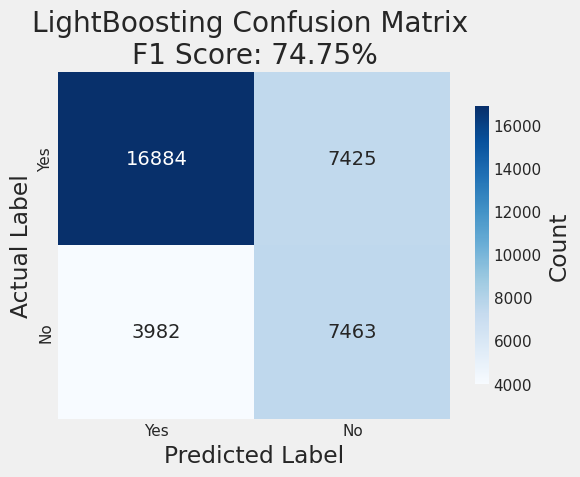

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict test labels using XGBoost
lgb_preds = lgb_model.predict(X_test)

# Generate confusion matrix
lgb_cm = confusion_matrix(y_test, lgb_preds)

# Extract values
TP = lgb_cm[1,1]
FP = lgb_cm[0,1]
FN = lgb_cm[1,0]
TN = lgb_cm[0,0]

# Compute F1 score
lgb_f1 = f1_score(y_test, lgb_preds, average="binary")   # use "macro" or "weighted" for multi-class
lgb_f1_percent = lgb_f1 * 100

# Create matrix with values
matrix_values = np.array([[TP, FP],
                          [FN, TN]])

# Create matrix with labels
matrix_labels = np.array([[f"{TP}", f"{FP}"],
                          [f"{FN}", f"{TN}"]])

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(matrix_values, annot=matrix_labels, fmt='', cmap='Blues',
            xticklabels=["Yes", "No"],
            yticklabels=["Yes", "No"],
            cbar=True, cbar_kws={"label": "Count", "shrink": 0.8})

plt.title(f"LightBoosting Confusion Matrix \nF1 Score: {lgb_f1_percent:.2f}%")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


In [ ]:
#import shap==v0.41.0
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# model: trained binary classification model
# X: feature dataframe used for training/testing

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


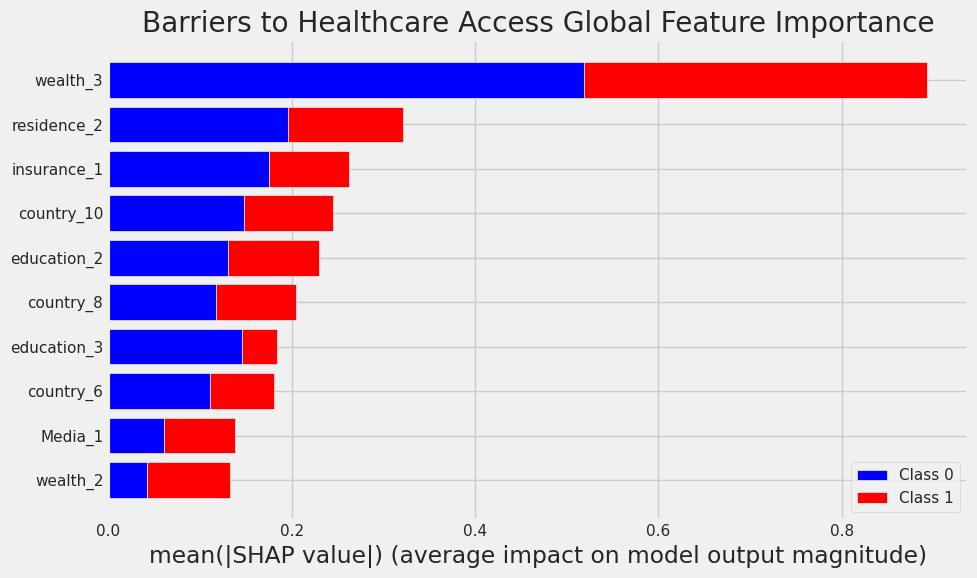

In [ ]:
# SHAP global feature importance plot
# If shap_values is Explanation, use .values
if hasattr(shap_values, "values"):
    shap_vals = shap_values.values
else:
    shap_vals = shap_values   # already numpy

# --------------------------------------------------
# 2. Predicted probabilities → class masks
# --------------------------------------------------
proba = lgb_model.predict_proba(X_test)[:, 1]
class0_mask = proba < 0.5
class1_mask = proba >= 0.5

# --------------------------------------------------
# 3. Class-wise mean(|SHAP|) per feature
# --------------------------------------------------
n_features = shap_vals.shape[1]

mean_shap_class0 = (
    np.mean(np.abs(shap_vals[class0_mask]), axis=0)
    if np.any(class0_mask)
    else np.zeros(n_features)
)

mean_shap_class1 = (
    np.mean(np.abs(shap_vals[class1_mask]), axis=0)
    if np.any(class1_mask)
    else np.zeros(n_features)
)

features = X_test.columns.to_numpy()

# --------------------------------------------------
# 4. Sort top features by total importance
# --------------------------------------------------
total_importance = mean_shap_class0 + mean_shap_class1
top_n = 10
top_idx = np.argsort(total_importance)[-top_n:][::-1]

features_top = features[top_idx]
class0_top = mean_shap_class0[top_idx]
class1_top = mean_shap_class1[top_idx]

# --------------------------------------------------
# 5. Stacked horizontal bar plot
# --------------------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(features_top, class0_top, color='blue', label='Class 0')
plt.barh(features_top, class1_top, left=class0_top, color='red', label='Class 1')
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.gca().invert_yaxis()
plt.legend()
plt.title("Barriers to Healthcare Access Global Feature Importance")
plt.tight_layout()
plt.show()


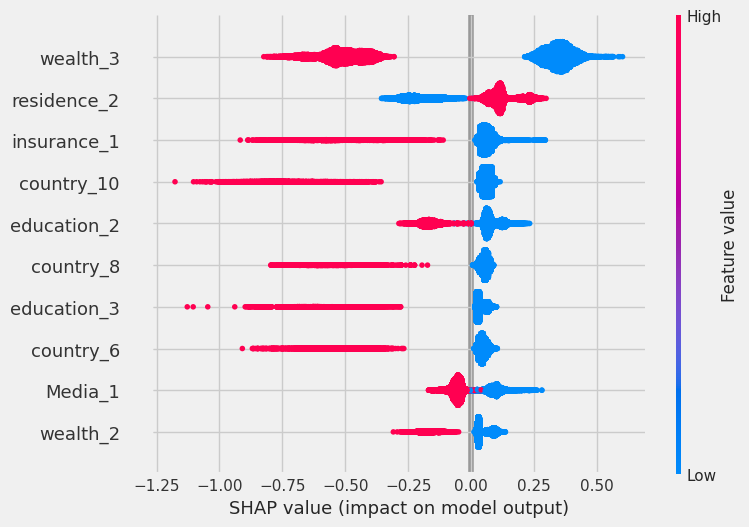

In [ ]:
# Beeswarm plot--------------------------------------------------
# 1. SHAP values already computed
# --------------------------------------------------
shap_vals = shap_values  # shape: (n_samples_test, n_features)

# --------------------------------------------------
# 2. Predicted probabilities → class masks
# --------------------------------------------------
proba = lgb_model.predict_proba(X_test)[:, 1]
class0_mask = proba < 0.5
class1_mask = proba >= 0.5

# Assign a color to each sample based on predicted class
colors = np.array(['blue' if p < 0.5 else 'red' for p in proba])

# --------------------------------------------------
# 3. Compute mean(|SHAP|) per feature for each class
# --------------------------------------------------
n_features = shap_vals.shape[1]

mean_shap_class0 = (
    np.mean(np.abs(shap_vals[class0_mask]), axis=0)
    if np.any(class0_mask)
    else np.zeros(n_features)
)
mean_shap_class1 = (
    np.mean(np.abs(shap_vals[class1_mask]), axis=0)
    if np.any(class1_mask)
    else np.zeros(n_features)
)

# Total importance across both classes
total_importance = mean_shap_class0 + mean_shap_class1

# --------------------------------------------------
# 4. Select top 10 features by total importance
# --------------------------------------------------
top_n = 10
top_idx = np.argsort(total_importance)[-top_n:][::-1]

X_top = X_test.iloc[:, top_idx]   # top features
shap_top = shap_vals[:, top_idx]
features_top = X_test.columns.to_numpy()[top_idx]

# --------------------------------------------------
# 5. SHAP summary plot (beeswarm) with fixed order
# --------------------------------------------------
shap.summary_plot(
    shap_top,                # SHAP values for top features
    X_top,                   # corresponding feature values
    feature_names=features_top,
    plot_type="dot",         # beeswarm style
    color=colors,            # color by predicted class
    max_display=top_n,
    sort=False               # keep the order we pass in
)
